## Time Series Analysis

When the data or the variable of your interest varies over a period of time, then we refer to that dataset as Time series data.
The analysis of such a dataset will allow us to look for trends, recurring patterns and also forecast.
When analyzing time series data, you should undertake a number of steps.

**First, you need to check for stationarity and autocorrelation.**
Stationarity is a way to measure if the data has structural patterns like seasonal trends.

The time series data can be composed of the following components

### Observation (t) = Trend(t)  + Seasonal Trend(t) + Impact Effects(t) + Noise

## Trend

When we look at the data over a long enough window, the data would be either increasing, decreasing or remains flat with time. This is referred to as Trend.


## Seasonality

This refers to repeating patterns in the time series data.

## Impact Effects

Anomalous spikes or dips that occurs at particular times are referred to as impact effects.

![Screenshot%202022-11-16%20at%202.54.00%20PM.png](attachment:Screenshot%202022-11-16%20at%202.54.00%20PM.png)
(https://structural-time-series.fastforwardlabs.com/)

The above underlying features can be identitfied using various analysing techniques.

When analyzing time series data, firstly, we need to check for stationarity and autocorrelation.

## 1. Stationarity: Stationary and Non-Stationary Time series

Allows us to measure if the data has structural pattern like trends in the data. A stationary time series will not have any trends. A time series is said to be stationary if it has constant mean, variance and the covariance is independent of time.

When the average value of a time series changes with time, one of several types of trend is present.

A global linear trend has a formulation similar to linear regression by formula

## $X_t = \alpha + \beta t + \epsilon_t$




### Different types of Trends in non-stationary time series

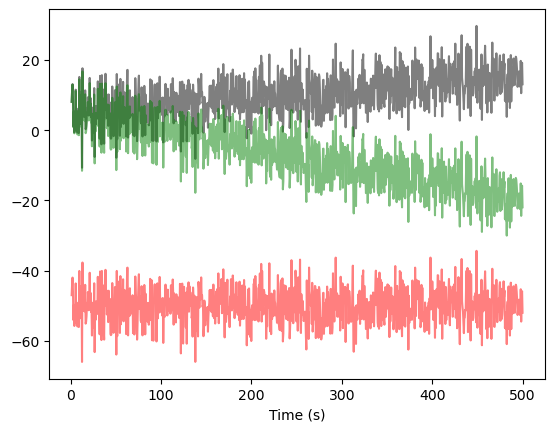

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 5
beta = 0.02
t = np.linspace(1,500,1000)
epsilon = np.random.normal(0,1,1000)*5


X1 = alpha + beta*t +epsilon
X2 = alpha -0.05*t +epsilon
X3 = -50 +0 *t + epsilon

plt.figure()
plt.plot(t,X1,'k-',alpha=0.5)
plt.plot(t,X2,'g-',alpha=0.5)
plt.plot(t,X3,'r-',alpha=0.5)
plt.xlabel('Time (s)')

plt.show()


### Non-stationary times series with linear trend + seasonal pattern

0.02


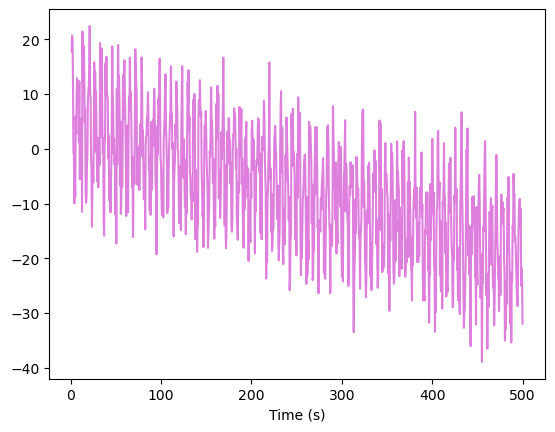

In [ ]:
omega = 2*np.pi*50
print(1/50.0)
X4 = alpha -0.05*t +epsilon + 10*np.sin(2*np.pi*omega*t+np.pi/4)

plt.figure()
plt.plot(t,X4,'m-',alpha=0.5)
plt.xlabel('Time (s)')
#plt.xlim([0,100])

plt.show()

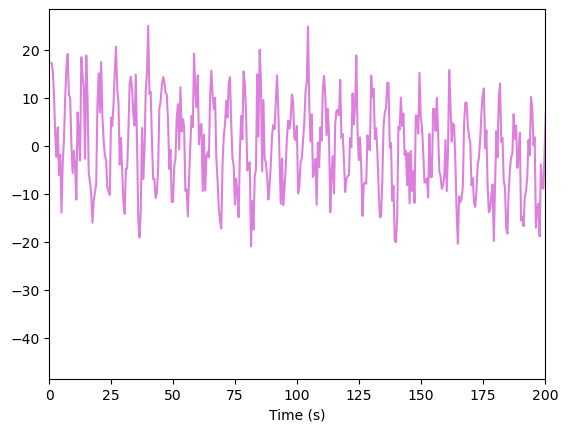

In [ ]:
plt.figure()
plt.plot(t,X4,'m-',alpha=0.5)
plt.xlabel('Time (s)')
plt.xlim([0,200])

plt.show()

### Detrend
For nonstationary signals which vary in amplitude in some systematic way, we can detrend the dataset with regression or nonparametric smoothers to create a quasi-stationary time series.

In the above example, we will need to remove the linear trend from the data. For that we can fit (as a part of regression) a linear (straight line) model to the data and then subtract that best fit model from the data to get a detrended data which would then show only the seasonal pattern (or the periodic pattern).

### -  Fourier Power Spectrum or Periodogram
Any time series can be expressed as a combination of cosine and sine waves with differing periods. A periodogram is used to identify the dominant periods (or frequencies) of a time series. This can be a helpful tool for identifying the dominant cyclical behavior in a series.

This analysis of the time series as a sum of cosine waves with varying amplitudes and frequencies is referred to as spectrum analysis in the domain of time series analysis.

Fourier analysis is designed for stationary time series with infinite duration and evenly spaced observations of sinusoidal periodic signals superposed on Gaussian (white) noise.

In practical, however, for example in many time series deviate from these assumptions with limited-duration observations, gaps or unevenly spaced observations, nonsinusoidal periodic signals, phase incoherence, Poissonian or 1/ f noise, or nonstationarity.

Consider a discrete signal x = ($x_1, x_2,...,x_N)$, where $N$ is the length of the signal.
Let the sample be sampled at a frequency of $f = \frac{1}{\Delta t}$, where $ \Delta t $ is time interval of the binning in seconds.

The total signal window is $T = (N-1) \Delta t$.

The power density is estimated as follows for a finite length of N no: of intervals,
![Screenshot%202023-11-14%20at%2011.49.01%20AM.png](attachment:Screenshot%202023-11-14%20at%2011.49.01%20AM.png)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         3265 non-null   int64  
 1   Date                               3265 non-null   object 
 2   Monthly_Mean_Total_Sunspot_Number  3265 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.7+ KB


/var/folders/1s/qv77bg195jj73d1b1tvlj5140000gn/T/ipykernel_5377/1647039590.py:11: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  ax2.locator_params(axis='x', nbins=5)


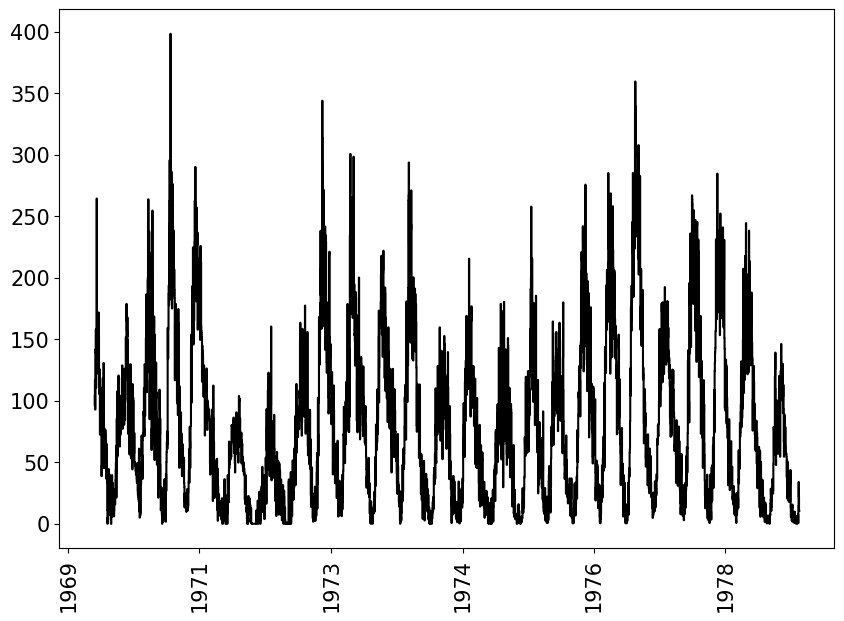

In [ ]:
import pandas as pd
df_sun = pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/Sunspots.csv')
df_sun.info()
Time =df_sun['Date']
sunspot = df_sun['Monthly_Mean_Total_Sunspot_Number']

import matplotlib.pyplot as plt
#Light curve plot
fig_sun, ax2 = plt.subplots(figsize=(10,7))
ax2.step(Time,sunspot, 'k')
ax2.locator_params(axis='x', nbins=5)
# ax2.set_xlim([-4,9])
# ax2.tick_params(axis='both',which='both', width=1,direction='in')
# ax2.tick_params(which='major', length=8)
# ax2.tick_params(which='minor', length=4)
# ax2.tick_params(labelsize=15)

# ax2.set_ylabel('Counts/bin/det', fontsize=21)
# ax2.set_xlabel('Time since Swift BAT trigger(s)', fontsize=21)

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter('%Y') # define the formatting
plt.gca().xaxis.set_major_formatter(dtFmt)
#plt.gca().xaxis.set_major_formatter(Time)
# show every 12th tick on x axes
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=20))
plt.xticks(rotation=90, fontweight='light',  fontsize='x-small',)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
plt.show()

In [ ]:
print(Time)
print(len(Time)/((2021-1749)*12))

0       1749-01-31
1       1749-02-28
2       1749-03-31
3       1749-04-30
4       1749-05-31
           ...    
3260    2020-09-30
3261    2020-10-31
3262    2020-11-30
3263    2020-12-31
3264    2021-01-31
Name: Date, Length: 3265, dtype: object
1.0003063725490196


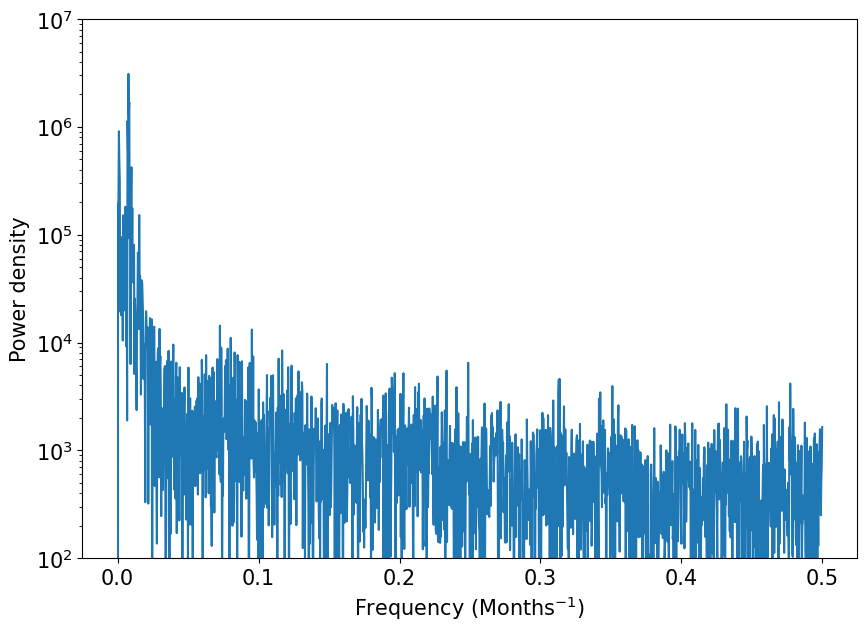

In [ ]:
from scipy import signal
fig, ax = plt.subplots(figsize=(10,7))
f, P_den = signal.periodogram(sunspot, 1) # ydata, sampling frequency of the data = total number of datapoints/ (total duration time)
plt.semilogy(f, P_den)
plt.ylim([1e2, 1e7])
#plt.xlim([1e-3, 5*1e-2])
plt.xlabel('Frequency (Months$^{-1}$)',fontsize=15)
plt.ylabel('Power density',fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
plt.show()


In [ ]:
print(np.max(P_den))
peak_freq = f[np.where(P_den == np.max(P_den))[0][0]]
period = (1/(peak_freq*12))
print('The sunspot cycle is ',np.round(period),'years.')

3102741.2423707615
The sunspot cycle is  11.0 years.


# Another example

0.1


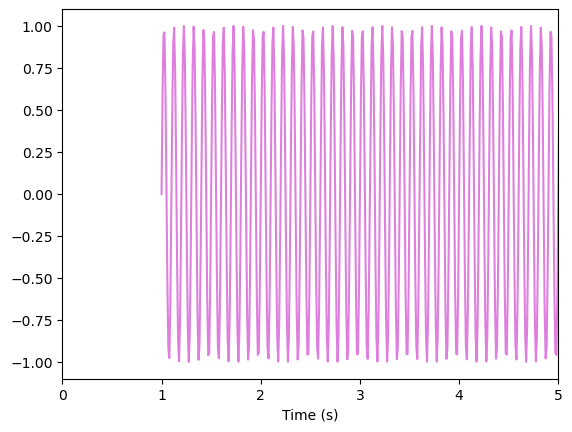

In [ ]:
t = np.linspace(1,50,5000)
nu = 10
print(1/10)
X5 = np.sin(2*np.pi*nu*t)
plt.figure()
plt.plot(t,X5,'m-',alpha=0.5)
plt.xlabel('Time (s)')
plt.xlim([0,5])

plt.show()

0.009801960392078257


<Figure size 640x480 with 0 Axes>

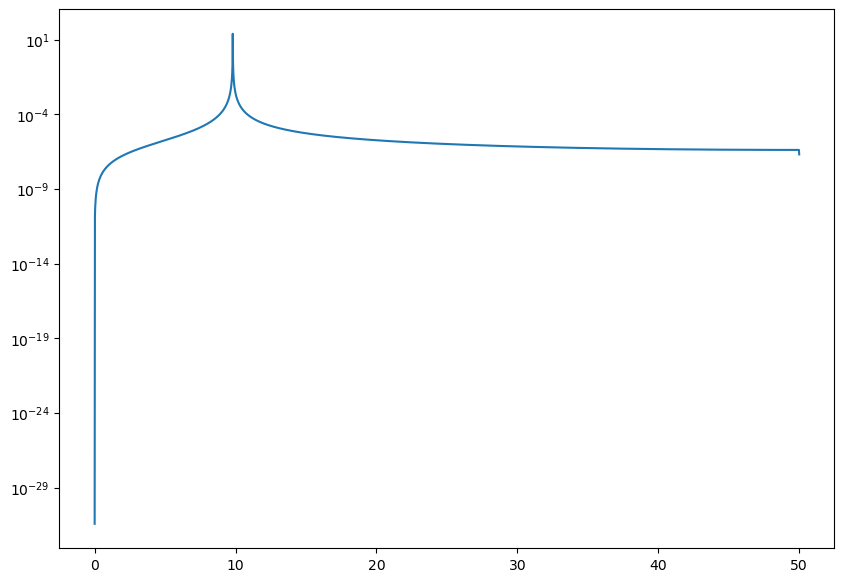

24.214545795376658
9.8
The periodicity is  0.102 s.


In [ ]:
plt.figure()
print(t[2]-t[1])
f_s, P_den_s = signal.periodogram(X5,len(X5)/50.)
fig, ax = plt.subplots(figsize=(10,7))
plt.semilogy(f_s, P_den_s)
#plt.xlim([0,0.1])
plt.show()

print(np.max(P_den_s))
peak_freq_s = f_s[np.where(P_den_s == np.max(P_den_s))[0][0]]
print(peak_freq_s)
period_s = (1/(peak_freq_s))
print('The periodicity is ',np.round(period_s,3),'s.')

## 2. Correlation

- ###  Autocorrelation
- Measures how similar a signal is to a time-shifted version of itself.
- It tells you about the internal repeating patterns or periodicities within a single time series.
- Used to detect:

(a) Oscillations, (b) Lags (c) Memory effects

Happens when the future values in a time series data linearly depend on the past values. In other words, the autocorrelation function establishes the degree to which values at different separations in time vary together,

## \begin{equation}
ACF(k) = \frac{\sum_{t=1}^{n-k}(X_t - \bar{X})(X_{t+k} - \bar{X})}{\sum_{t=1}^n (X_t - \bar{X})^2}
\end{equation}

where $\bar{X}$ is the mean of the time series. The integer parameter, $k > 0$ here is called the lag time, the numerator is the sample autocovariance function and the denominator is the sample variance.

### The plot of ACF(k) for a range of k is often called the correlogram.

### Time series with short-term autocorrelation have strong ACF coefficients at small k, while time series with long-term memory have ACF signals for a wide range of k.

![Screenshot%202022-11-17%20at%208.39.39%20AM.png](attachment:Screenshot%202022-11-17%20at%208.39.39%20AM.png)
(From paper Application of Autocorrelation and Crosscorrelation Analyses in Human Movement
and Rehabilitation Research)

![Screenshot%202022-11-17%20at%208.56.18%20AM.png](attachment:Screenshot%202022-11-17%20at%208.56.18%20AM.png)

Autocorrelation can be used to identify if the time series data is stationary or not. If stationary as shown in the right hand plot in the above figure, the correlogram will have very few significant spikes at very small lags and cuts off drastically/dies down quickly for stationary series. On the other hand, for non-stationary series, the decay in ACF will be slow and gradual as shown in the left hand figure.

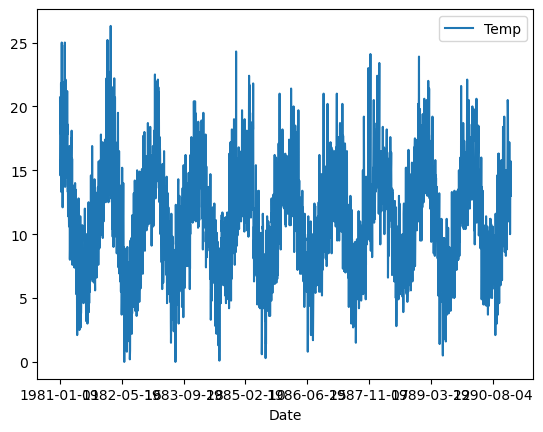

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
series = pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132_6132_Statistical_and_data_analysis_in_Physical_Sciences/Statistics_Modules/DataSets/min_temp_melbourne.txt', header=0, index_col=0)
series.plot()
plt.show()

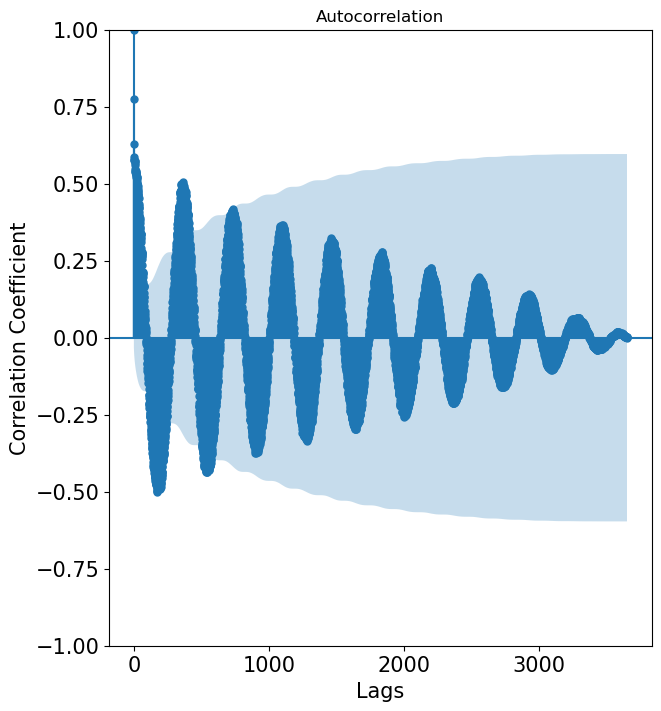

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

 # if provided int it will consider np.arange(lags)
fig_auto, ax = plt.subplots(figsize=(7,8))
plot_acf(series,lags =len(series)-1,alpha = 0.05,ax=ax)
plt.xlabel('Lags',fontsize=15)
plt.ylabel('Correlation Coefficient',fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
plt.show()

### The shaded region represents confidence intervals for testing whether autocorrelation at each lag is zero. If points lie within the band, there is no statistically significant linear correlation at those lags, though this does not guarantee independence.

In order to assess how trustworthy these autocorrelation values are, the plot_acf() function also returns confidence intervals represented as blue shaded regions. If an autocorrelation value goes beyond the confidence interval region, you can assume that the observed autocorrelation value is statistically significant. It means there exists a strong correlation or trend in the data.

### KeyPoints One can Assess from the above ACF plot

1. A clear periodic signal
2. With damped correlations
3. ACF decays toward zero - Suggests the series is stationary
4. Lag is significant in the lower values.

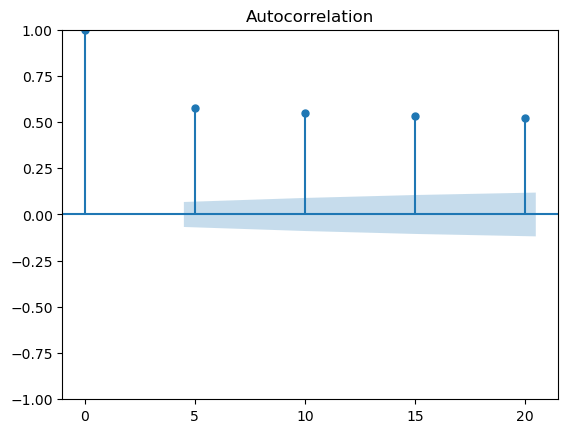

In [ ]:
# An expanded plot in the lower lags are shown - indicating higher statistical significance for auto-correlation
plot_acf(series,lags =[0,5,10,15,20])
plt.show()

![Screenshot%202022-11-17%20at%208.47.53%20AM.png](attachment:Screenshot%202022-11-17%20at%208.47.53%20AM.png)

- ###  Cross - Correlation
- Measures how similar two different signals are when one is shifted in time relative to the other.

- It tells you if there's a lag or lead relationship between two signals.

- Used to detect:

(a) Time delays between correlated signals (b) Causal relationships and (c) Signal alignment

**Note: Standardisation of the datasets are necessary for applying the cross-correlation techniques.**

Cross correlation is the technique used to measure the correlation or similarity between two sets of time series dataset. In other words, cross-correlation is a measure of similarity of two series as a function of the displacement of one relative to the other. So, we keep one signal fixed and slide the other signal at different lags and estimate the similarity between the two curves.

![Illustration_cross_correlation.gif](attachment:Illustration_cross_correlation.gif)
(Credits: Cross-Correlation in Python by Jake)

Auto-correlation is a special case of cross-correlation where the cross-correlation is taken with respect to the signal itself.

![Screenshot%202022-11-17%20at%208.42.56%20AM.png](attachment:Screenshot%202022-11-17%20at%208.42.56%20AM.png)

The quantity $\tau .f_s$ represents the phase shift of the discretely sampled signals is an integer.

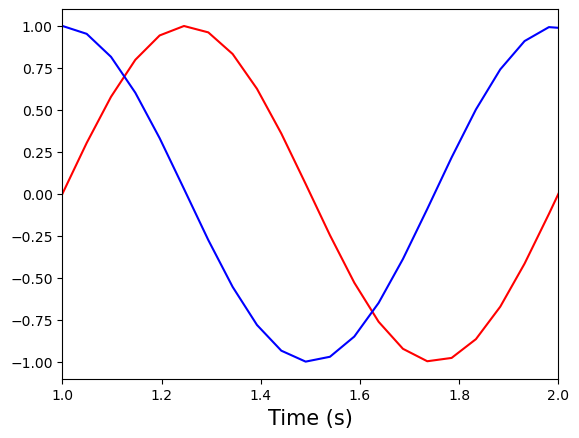

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(1,50,1000)
nu = 1
# First signal
sig1 = np.sin(2*np.pi*nu*t)

# Seconds signal with pi/2 phase shift.
sig2 = np.sin(2*np.pi*nu*t+np.pi/2)

plt.figure()
plt.plot(t, sig1,'r-')
plt.plot(t, sig2,'b-')
plt.xlabel('Time (s)',fontsize=15)
plt.xlim([1,2])
plt.show()

In [ ]:
# import scipy.signal

# corr = scipy.signal.correlate(sig1, sig2,mode='same',method='direct')/(len(sig2) * np.std(sig1) * np.std(sig2))

# #print(corr)


In [ ]:
# The function is copied from the scipy source code.
def correlation_lags(in1_len, in2_len, mode='full'):
    r"""
    Calculates the lag / displacement indices array for 1D cross-correlation.
    Parameters
    ----------
    in1_len : int
        First input size.
    in2_len : int
        Second input size.
    mode : str {'full', 'valid', 'same'}, optional
        A string indicating the size of the output.
        See the documentation `correlate` for more information.
    See Also
    --------
    correlate : Compute the N-dimensional cross-correlation.
    Returns
    -------
    lags : array
        Returns an array containing cross-correlation lag/displacement indices.
        Indices can be indexed with the np.argmax of the correlation to return
        the lag/displacement.
    Notes
    -----
    Cross-correlation for continuous functions :math:`f` and :math:`g` is
    defined as:
    .. math::
        \left ( f\star g \right )\left ( \tau \right )
        \triangleq \int_{t_0}^{t_0 +T}
        \overline{f\left ( t \right )}g\left ( t+\tau \right )dt
    Where :math:`\tau` is defined as the displacement, also known as the lag.
    Cross correlation for discrete functions :math:`f` and :math:`g` is
    defined as:
    .. math::
        \left ( f\star g \right )\left [ n \right ]
        \triangleq \sum_{-\infty}^{\infty}
        \overline{f\left [ m \right ]}g\left [ m+n \right ]
    Where :math:`n` is the lag.
    Examples
    --------
    Cross-correlation of a signal with its time-delayed self.
    >>> from scipy import signal
    >>> from numpy.random import default_rng
    >>> rng = default_rng()
    >>> x = rng.standard_normal(1000)
    >>> y = np.concatenate([rng.standard_normal(100), x])
    >>> correlation = signal.correlate(x, y, mode="full")
    >>> lags = signal.correlation_lags(x.size, y.size, mode="full")
    >>> lag = lags[np.argmax(correlation)]
    """

    # calculate lag ranges in different modes of operation
    if mode == "full":
        # the output is the full discrete linear convolution
        # of the inputs. (Default)
        lags = np.arange(-in2_len + 1, in1_len)
    elif mode == "same":
        # the output is the same size as `in1`, centered
        # with respect to the 'full' output.
        # calculate the full output
        lags = np.arange(-in2_len + 1, in1_len)
        # determine the midpoint in the full output
        mid = lags.size // 2
        # determine lag_bound to be used with respect
        # to the midpoint
        lag_bound = in1_len // 2
        # calculate lag ranges for even and odd scenarios
        if in1_len % 2 == 0:
            lags = lags[(mid-lag_bound):(mid+lag_bound)]
        else:
            lags = lags[(mid-lag_bound):(mid+lag_bound)+1]
    elif mode == "valid":
        # the output consists only of those elements that do not
        # rely on the zero-padding. In 'valid' mode, either `in1` or `in2`
        # must be at least as large as the other in every dimension.

        # the lag_bound will be either negative or positive
        # this let's us infer how to present the lag range
        lag_bound = in1_len - in2_len
        if lag_bound >= 0:
            lags = np.arange(lag_bound + 1)
        else:
            lags = np.arange(lag_bound, 1)
    return lags

In [ ]:
from scipy import signal

correlation_coeff = signal.correlate(sig1, sig2, mode="same")/(len(sig2) * np.std(sig1) * np.std(sig2)) # output is normalized correlation coefficient to lie between +1 and -1.
lags = correlation_lags(sig1.size, sig2.size, mode="same")
lag = lags[np.argmax(correlation_coeff)]
print(lag) # Note here the lag represents the no: of sliding steps it has considered in units of 1.
# in the above example the time step is given by
time_step = 50/1000
#Therefore, the time delay between the two time series data is
print('The time delay between the two time series data is ',lag*time_step)

5
The time delay between the two time series data is  0.25


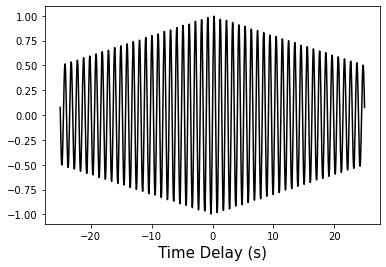

In [ ]:
plt.figure()
plt.plot(lags*time_step, correlation_coeff,'k-')
#plt.xlim([0,30])
plt.xlabel('Time Delay (s)',fontsize=15)
plt.show()

### The time delay is that time difference in the sliding of the two signals where both the signals become highly similar or correlated.

One of the most powerful and useful output measures resulting from crosscorrelation is the temporal shift, or phase
delay ($\tau_{delay}$), of one signal relative to the other. The $\tau$ value has units of time, and can vary between 0 and the total duration of the record in both positive and negative directions. The temporal shift provides information about when signal events are happening relative to each other in each of the signals used for the autocorrelation or cross-correlation.

**In correlate(sig1, sig2)==> lag tells how much sig2 must shift to match sig1**

**Positive lag -->  sig1 leads sig2, Negative lag --> sig2 leads sig1**

**In other words, Positive lag ($\tau>0$)
--> sig2 is shifted to the right
--> sig2 happens later
==> sig1 leads sig2**

**Negative lag ($\tau<0$)
--> sig2 is shifted to the left
--> sig2 happens earlier
==> sig2 leads sig1**

### The similarity of the two signals are given by the measure of correlation coefficient at the time delay.

### Note: In cross-correlation, the lengths of the two signals should be the same.  

## Dynamic Time Warping  (DTW)

Dynamic Time Warping allows for comparing two timeseries even when the compared time series are of different length and frequency.


Generally two time series data are compared by measuring the euclidean distances on a one to one basis on time axis, as shown in the figure below.  

![Screenshot%202022-11-21%20at%207.36.54%20PM.png](attachment:Screenshot%202022-11-21%20at%207.36.54%20PM.png)

(Time Series Similarity Using Dynamic Time Warping -Explained by Abhishek Mishra)

In such a case, even when the two time series are similar in shape but out of phase, it would result in low similarity score.

However, DTW compares amplitude of first signal at time T with amplitude of second signal at time T+1 and T-1 or T+2 and T-2, and so on.  
This makes sure it does not give low similarity score for signals with similar shape and different phase or frequency.

![Screenshot%202022-11-21%20at%208.34.21%20PM.png](attachment:Screenshot%202022-11-21%20at%208.34.21%20PM.png)

![Screenshot%202022-11-21%20at%209.03.32%20PM.png](attachment:Screenshot%202022-11-21%20at%209.03.32%20PM.png)

### Create a Cost Matrix or Distance matrix

![Screenshot%202022-11-21%20at%209.04.13%20PM.png](attachment:Screenshot%202022-11-21%20at%209.04.13%20PM.png)

![Screenshot%202022-11-21%20at%209.05.16%20PM.png](attachment:Screenshot%202022-11-21%20at%209.05.16%20PM.png)

![Screenshot%202022-11-21%20at%209.06.42%20PM.png](attachment:Screenshot%202022-11-21%20at%209.06.42%20PM.png)

![Screenshot%202022-11-21%20at%209.07.24%20PM.png](attachment:Screenshot%202022-11-21%20at%209.07.24%20PM.png)

### Warping Path Identification

![Screenshot%202022-11-21%20at%209.09.11%20PM.png](attachment:Screenshot%202022-11-21%20at%209.09.11%20PM.png)

### Final path will look like this...

![Screenshot%202022-11-21%20at%209.10.05%20PM.png](attachment:Screenshot%202022-11-21%20at%209.10.05%20PM.png)


### This warping distance is referred to as d

![Screenshot%202022-11-21%20at%209.11.50%20PM.png](attachment:Screenshot%202022-11-21%20at%209.11.50%20PM.png)

## Final distance calculation

![Screenshot%202022-11-21%20at%209.12.59%20PM.png](attachment:Screenshot%202022-11-21%20at%209.12.59%20PM.png)


### where 'k' is the length of series of 'd'

![Screenshot%202022-11-21%20at%209.15.42%20PM.png](attachment:Screenshot%202022-11-21%20at%209.15.42%20PM.png)

In [ ]:
import pandas as pd
import numpy as np
# Plotting Packages
import matplotlib.pyplot as plt
import seaborn as sbn
# Configuring Matplotlib
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
savefig_options = dict(format="png", dpi=300, bbox_inches="tight")
# Computation packages
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

In [ ]:
import pandas as pd
series1 = pd.Series([1,4,5,10,9,3,2,6,8,4])
series2 = pd.Series([1,7,3,4,1,10,5,4,7,4])

##Fill DTW Matrix
def fill_dtw_cost_matrix(s1, s2):
    l_s_1, l_s_2 = len(s1), len(s2)
    cost_matrix = np.zeros((l_s_1+1, l_s_2+1))
    for i in range(l_s_1+1):
        for j in range(l_s_2+1):
            cost_matrix[i, j] = np.inf
    cost_matrix[0, 0] = 0

    for i in range(1, l_s_1+1):
        for j in range(1, l_s_2+1):
            cost = (abs(s1[i-1] - s2[j-1]))**2. # either you take the absolute or you take the square of (s1[i-1] - s2[j-1])
            #take last min from the window
            prev_min = np.min([cost_matrix[i-1, j], cost_matrix[i, j-1], cost_matrix[i-1, j-1]])
            cost_matrix[i, j] = cost + prev_min
    return cost_matrix

 ##Call DTW function
dtw_cost_matrix = fill_dtw_cost_matrix(series1,series2)

In [ ]:
print(dtw_cost_matrix)

[[  0.  inf  inf  inf  inf  inf  inf  inf  inf  inf  inf]
 [ inf   0.  36.  40.  49.  49. 130. 146. 155. 191. 200.]
 [ inf   9.   9.  10.  10.  19.  55.  56.  56.  65.  65.]
 [ inf  25.  13.  13.  11.  26.  44.  44.  45.  49.  50.]
 [ inf 106.  22.  62.  47.  92.  26.  51.  80.  54.  85.]
 [ inf 170.  26.  58.  72. 111.  27.  42.  67.  58.  79.]
 [ inf 174.  42.  26.  27.  31.  76.  31.  32.  48.  49.]
 [ inf 175.  67.  27.  30.  28.  92.  40.  35.  57.  52.]
 [ inf 200.  68.  36.  31.  53.  44.  41.  39.  36.  40.]
 [ inf 249.  69.  61.  47.  80.  48.  50.  55.  37.  52.]
 [ inf 258.  78.  62.  47.  56.  84.  49.  49.  46.  37.]]


36.99999999999999


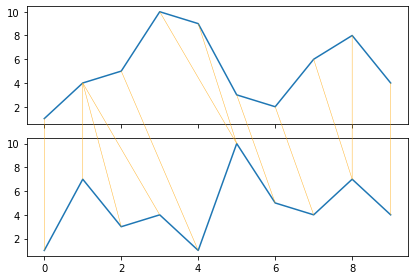

In [ ]:
#https://dtaidistance.readthedocs.io/en/latest/usage/installation.html
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np

path = dtw.warping_path(series1, series2)
dtwvis.plot_warping(series1, series2, path)
distance = dtw.distance(series1, series2)
print(distance**2.)

## Above figure shows the optimal distances between all points of the two time series.

(<Figure size 720x720 with 4 Axes>,
 [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>])

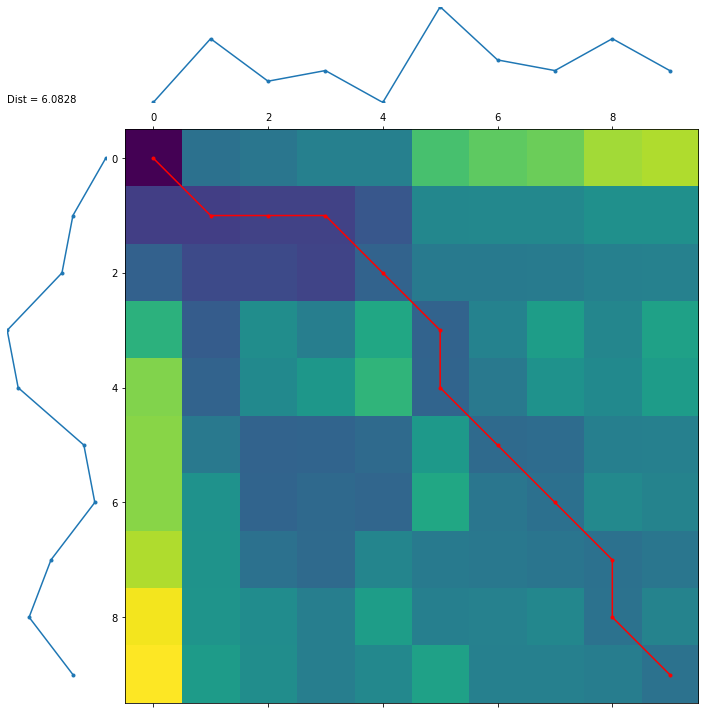

In [ ]:
# In a general case, one element in an array is allowed to match an unlimited number of elements in the other array.
# we can add a window constraint to limit the number of elements one can match
d, paths = dtw.warping_paths(series1, series2, window=None, use_pruning=False )
#Here the distance between series1 and series2 is the last element of the matrix,
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(series1, series2, paths, best_path)

### The darker the color, the lower the distance. The optimal warping path is extracted (red line).

In [ ]:
print(np.array(paths)) # Here the distance matrix is computed by taking (s1[i-1] - s2[j-1])**2. + min(....)
#and the obtained distances square roots are taken and reported in the distance matrix

[[ 0.                 inf         inf         inf         inf         inf
          inf         inf         inf         inf         inf]
 [        inf  0.          6.          6.32455532  7.          7.
  11.40175425 12.08304597 12.4498996  13.82027496 14.14213562]
 [        inf  3.          3.          3.16227766  3.16227766  4.35889894
   7.41619849  7.48331477  7.48331477  8.06225775  8.06225775]
 [        inf  5.          3.60555128  3.60555128  3.31662479  5.09901951
   6.63324958  6.63324958  6.70820393  7.          7.07106781]
 [        inf 10.29563014  4.69041576  7.87400787  6.8556546   9.59166305
   5.09901951  7.14142843  8.94427191  7.34846923  9.21954446]
 [        inf 13.03840481  5.09901951  7.61577311  8.48528137 10.53565375
   5.19615242  6.4807407   8.18535277  7.61577311  8.88819442]
 [        inf 13.19090596  6.4807407   5.09901951  5.19615242  5.56776436
   8.71779789  5.56776436  5.65685425  6.92820323  7.        ]
 [        inf 13.22875656  8.18535277  5.19615242

In [ ]:
print(np.array(paths**2.))

[[  0.  inf  inf  inf  inf  inf  inf  inf  inf  inf  inf]
 [ inf   0.  36.  40.  49.  49. 130. 146. 155. 191. 200.]
 [ inf   9.   9.  10.  10.  19.  55.  56.  56.  65.  65.]
 [ inf  25.  13.  13.  11.  26.  44.  44.  45.  49.  50.]
 [ inf 106.  22.  62.  47.  92.  26.  51.  80.  54.  85.]
 [ inf 170.  26.  58.  72. 111.  27.  42.  67.  58.  79.]
 [ inf 174.  42.  26.  27.  31.  76.  31.  32.  48.  49.]
 [ inf 175.  67.  27.  30.  28.  92.  40.  35.  57.  52.]
 [ inf 200.  68.  36.  31.  53.  44.  41.  39.  36.  40.]
 [ inf 249.  69.  61.  47.  80.  48.  50.  55.  37.  52.]
 [ inf 258.  78.  62.  47.  56.  84.  49.  49.  46.  37.]]


In [ ]:
print(np.sqrt(np.array(paths**2.)[-1,-1]))

6.082762530298219


In [ ]:
print(best_path)

[(0, 0), (1, 1), (1, 2), (1, 3), (2, 4), (3, 5), (4, 5), (5, 6), (6, 7), (7, 8), (8, 8), (9, 9)]


In [ ]:
d_=[]
for v in best_path:
    i = v[0]+1
    j = v[1]+1
    #print(i,j)
    d_.append(paths[i,j])

dist = np.sum(d_)/len(d_)
print(dist)

4.530676331396253


In [ ]:
x = np.arange(0, 20, 2)
s1 = np.sin(x)
s2 = np.sin(x - 1)

In [ ]:
dtw_cost_matrix_ = fill_dtw_cost_matrix(s1,s2)
print(dtw_cost_matrix_)

[[ 0.                 inf         inf         inf         inf         inf
          inf         inf         inf         inf         inf]
 [        inf  0.70807342  1.41614684  1.43606169  2.35559746  2.78722885
   2.95707049  3.95705091  4.13359125  4.55646552  5.48075066]
 [        inf  3.77326345  0.71267384  1.30277039  4.79302272  2.41925821
   2.66644511  6.31182438  4.19629945  4.20067721  7.70017669]
 [        inf  3.7804322   3.26715196  1.51893867  1.3436236   3.34242321
   3.78563447  2.72558537  4.11084265  6.09074587  4.24253633]
 [        inf  4.09633857  4.52353847  1.69578878  1.80535578  2.22047249
   2.69869174  3.21791965  3.2150011   4.0793494   4.54444883]
 [        inf  7.44827425  4.11820921  2.41529689  5.49159356  1.91582669
   2.24903244  6.2065397   3.53897973  3.32996984  7.13541779]
 [        inf  7.53675067  6.03779756  2.88471524  2.58744152  3.35824621
   2.83002962  2.45694025  3.38659904  4.75634371  3.50417288]
 [        inf  7.62971351  7.93680256  3.

(<Figure size 720x720 with 4 Axes>,
 [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>])

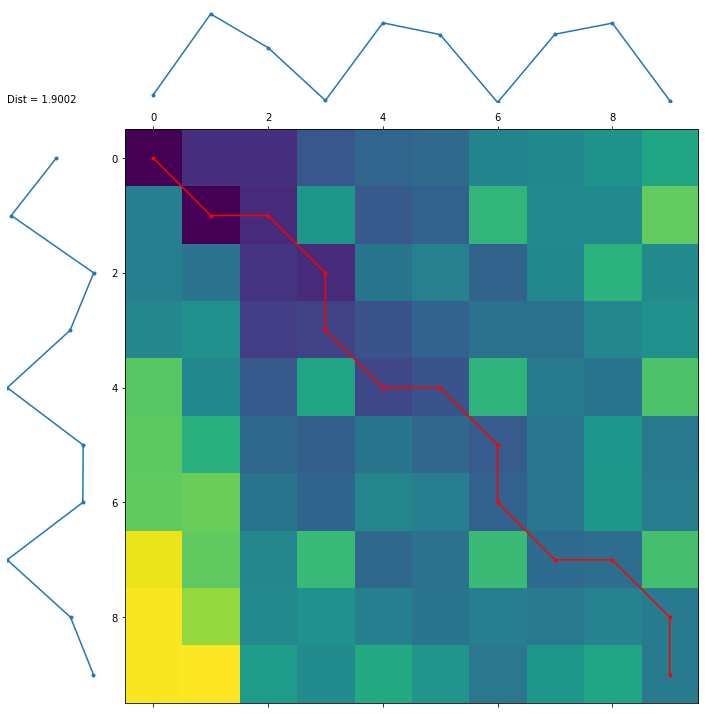

In [ ]:
d, paths = dtw.warping_paths(s1, s2, window=None, use_pruning=False )
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(s1, s2, paths, best_path)

In [ ]:
print(np.array(paths**2))

[[ 0.                 inf         inf         inf         inf         inf
          inf         inf         inf         inf         inf]
 [        inf  0.70807342  1.41614684  1.43606169  2.35559746  2.78722885
   2.95707049  3.95705091  4.13359125  4.55646552  5.48075066]
 [        inf  3.77326345  0.71267384  1.30277039  4.79302272  2.41925821
   2.66644511  6.31182438  4.19629945  4.20067721  7.70017669]
 [        inf  3.7804322   3.26715196  1.51893867  1.3436236   3.34242321
   3.78563447  2.72558537  4.11084265  6.09074587  4.24253633]
 [        inf  4.09633857  4.52353847  1.69578878  1.80535578  2.22047249
   2.69869174  3.21791965  3.2150011   4.0793494   4.54444883]
 [        inf  7.44827425  4.11820921  2.41529689  5.49159356  1.91582669
   2.24903244  6.2065397   3.53897973  3.32996984  7.13541779]
 [        inf  7.53675067  6.03779756  2.88471524  2.58744152  3.35824621
   2.83002962  2.45694025  3.38659904  4.75634371  3.50417288]
 [        inf  7.62971351  7.93680256  3.

In [ ]:
d_=[]
for v in best_path:
    i = v[0]+1
    j = v[1]+1
    #print(i,j)
    d_.append(paths[i,j])

dist = np.sum(d_)/len(d_)
print(dist)
print(d_)

1.4384565647938234
[0.8414709848078965, 0.8442001211267167, 1.141389675444838, 1.1591477925190512, 1.34363528615234, 1.384133914953497, 1.4996774442007224, 1.567462998875133, 1.6345322989069098, 1.7312128677780774, 1.764345591491714, 1.8885205241839693, 1.9002058418788352]
